Dylan Ross

Select out subsets of the omics data based on targeted pairwise comparisons

## Setup

### Imports

In [16]:
import os
from typing import List
import pickle

import polars as pl
import numpy as np
from scipy import stats
from plotly import graph_objects as pgo
from matplotlib import pyplot as plt, patches, rcParams

### Constants

In [17]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")
OMICS_CACHE = os.path.join(CACHE_DIR, "combined.arrow")


# key: block label
# value: color
COLORS = {
    "Transcriptomics": "#EF476F",
    "Phosphoproteomics": "#F7866B",
    "Proteomics": "#FFD166",
    "Acetylomics": "#06D6A0",
    "Lipidomics": "#11A2B2",
    "Metabolomics": "#0B6584",
    "Filtered": "#444444"
}

### Load metadata and omics data from cache

In [18]:
meta = pl.read_ipc(META_CACHE)
meta

Sample,Age,Sex,Race,Study,FLT3_ITD,NPM1
str,f64,str,str,str,bool,bool
"""11-00261""",74.0,"""Male""","""White""","""BeatAML""",true,false
"""11-00503""",54.0,"""Female""","""White""","""BeatAML""",true,true
"""11-00475""",65.0,"""Male""","""White""","""BeatAML""",true,true
"""12-00032""",70.0,"""Male""","""White""","""BeatAML""",true,false
"""11-00376""",49.0,"""Male""","""White""","""BeatAML""",true,true
…,…,…,…,…,…,…
"""16-01109-Bridge""",33.0,"""Male""","""Black""","""pilotStudy""",false,false
"""16-01191-Bridge""",65.0,"""Female""","""White""","""pilotStudy""",false,false
"""17-00025-Bridge""",39.0,"""Female""","""White""","""pilotStudy""",true,true


In [19]:
combined = pl.read_ipc(OMICS_CACHE)
combined

Block,Feature,11-00261,11-00503,11-00475,12-00032,11-00376,11-00378,11-00382,11-00388,11-00416,11-00465,11-00466,12-00123,12-00127,12-00145,12-00196,12-00294,12-00383,13-00033,13-00034,13-00075,13-00077,13-00123,13-00149,13-00157,13-00160,13-00186,13-00195,13-00226,13-00262,13-00331,13-00450,13-00468,14-00495,13-00558,13-00581,…,C-95-068,C-01-1665,C-09-1033,C-99-2136,C-05-1782,94-C-376,PS88-0050,C-01-2163,C-02-0350,C-04-0434,C-01-0171,PS88-0140,C-11-2295,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-01-0930,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-99-1700,C-02-1356,C-99-2065,14-00528-Bridge,16-00120-Bridge,16-00494-Bridge,16-00627-Bridge,16-00731-Bridge,16-01100-Bridge,16-01109-Bridge,16-01191-Bridge,17-00025-Bridge,17-00741-Bridge,17-00881-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",-2.79,-1.32,-0.07,-0.762,null,null,-1.88,-2.1,-1.38,1.17,-1.37,0.484,null,-0.946,0.496,null,null,0.669,-0.13,-0.141,0.371,null,2.2,0.564,null,0.0392,1.01,-0.326,-0.0122,0.681,null,null,2.34,-0.522,0.571,…,-0.740195,0.056017,1.525606,-0.970053,0.912385,0.415692,-0.3854,-1.527722,-0.465969,-0.417754,0.374158,-0.285991,1.689777,-0.286936,-1.355843,-1.783394,-0.108936,-1.092201,-0.704166,0.16671,-0.802912,0.24294,-1.08595,-0.37591,1.766804,-1.017518,-1.686547,-2.171659,-1.095024,-1.067707,-0.778423,-0.543555,0.740597,0.360673,0.027206,-0.568194,0.311076
"""Acetylomics""","""ACAD9-K202k""",-0.195,-0.357,-0.36,null,0.905,0.207,-0.834,-0.373,null,0.0433,-0.799,null,-2.44,0.438,-0.0222,-0.513,0.389,null,null,-0.544,0.155,-0.136,null,-0.471,-0.511,0.214,1.19,null,0.694,-1.3,0.189,null,2.15,1.17,0.523,…,-0.07763,null,0.570992,null,1.1831,-1.511869,-0.009541,null,-1.085725,null,0.674999,-0.25304,1.075163,null,-0.507267,null,1.627,-0.660512,-0.644078,null,-0.622194,null,1.45712,0.155145,-1.235691,null,null,-0.566252,-0.724165,0.207464,-0.395339,0.362696,0.286919,-0.602037,0.194048,null,null
"""Acetylomics""","""ACADM-K304k""",-0.129,-0.0232,0.367,null,0.35,null,-0.53,0.457,-1.13,-1.24,1.59,0.114,-0.0785,-1.07,0.286,null,1.26,null,-0.313,0.366,-0.803,-1.18,1.79,0.585,-1.46,-0.663,1.05,1.96,-1.03,0.729,0.421,null,1.39,null,null,…,-0.025817,null,-0.310245,-1.19684,0.517396,0.369655,-0.694533,null,-2.428373,-0.117239,0.130378,-0.284755,1.54642,null,-1.205137,-1.247686,0.675267,-1.064369,-0.076896,null,-1.371136,0.38916,-1.102276,-1.272929,0.014274,null,null,-2.467522,-0.71158,-0.672011,-1.563158,-1.060444,0.034066,-0.994443,-0.024539,-0.595167,null
"""Acetylomics""","""ACADVL-K278k""",0.272,0.81,0.265,null,1.43,null,null,null,null,0.658,0.563,1.16,0.726,-1.03,1.4,-0.328,-0.582,-2.29,0.596,1.13,null,-0.225,1.37,-0.82,null,-1.46,0.175,0.0792,0.507,0.52,-0.926,null,-0.152,null,-1.26,…,-0.416003,-0.432192,1.182928,-1.049746,-1.909679,-0.075547,-0.960016,-0.708188,-1.025387,-0.443936,1.004101,-0.314048,1.280458,0.231344,-0.711069,-0.104481,-0.064754,-1.169472,0.946654,-1.107658,-0.412209,1.016264,-2.307984,-0.028166,0.831407,-2.584908,0.002312,-1.849316,-0.621441,-2.109005,-1.389221,-0.992909,0.247213,-1.049815,0.351727,-0.419173,-1.870117
"""Acetylomics""","""ACADVL-K298k""",-0.622,0.421,-0.478,-2.19,1.26,null,null,2.19,-0.656,0.235,0.0553,0.699,-0.605,0.465,0.915,null,1.16,null,null,0.149,0.188,0.265,0.865,-0.456,0.31,-0.647,1.38,null,-0.979,null,-1.5600e-25,null,0.974,-0.542,-1.03,…,-1.109983,-0.410377,0.883659,-0.129818,-0.651763,0.020461,0.199043,-0.233644,-0.517838,-0.023063,0.561925,0.312539,0.861988,0.109789,-0.905637,0.285302,-0.125828,-0.331017,0.154637,0.459963,-0.478133,0.02304,-0.588967,-0.360287,-0.094358,-0.797413,0.303983,0.212966,-1.009953,-0.655982,-0.293991,-0.178373,-0.209228,-0.471836,-0.166835,-1.296326,-0.359604
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

In [20]:
# report on the number of features in each block
combined.group_by("Block").len().sort("len", descending=True)

Block,len
str,u32
"""Transcriptomics""",22116
"""Phosphoproteomics""",8362
"""Proteomics""",8059
"""Acetylomics""",935
"""Lipidomics""",343
"""Metabolomics""",49


## Summarize coverage of omics data by mutation state and population

In [21]:
def _count_samples_with_block_and_total(
    race,
    mut,
    block,
):
    # filter metadata by race 
    _meta = meta.filter(pl.col("Race") == race)
    # filter metadata by mutations
    match mut:
        case "WT":
            _meta = _meta.filter(
                ~pl.col("NPM1")
                & ~pl.col("FLT3_ITD")
            )
        case "NPM1":
            _meta = _meta.filter(
                pl.col("NPM1")
                & ~pl.col("FLT3_ITD")
            )
        case "FLT3-ITD": 
            _meta = _meta.filter(
                ~pl.col("NPM1")
                & pl.col("FLT3_ITD")
            )
        case "NPM1xFLT3-ITD":
            _meta = _meta.filter(
                pl.col("NPM1")
                & pl.col("FLT3_ITD")
            )
    samples = _meta["Sample"].to_list()
    # count the number of samples that have the specified block
    # criterion for "having the block" is not all values are null
    # in that column
    _combined = (
        combined
        .filter(pl.col("Block") == block)
        .select(samples)
    )
    all_rows = len(_combined)
    has_block = len(
        _combined
        .null_count()
        .select(
            pl.all().eq(all_rows)
        )
        .transpose()
        .filter(~pl.col("column_0"))
    )
    return has_block, len(samples)


# key: (race label, mutation label, block)
# value: (sample count with block, sample count with or without block)
omics_counts = {
    (race == "Black", mut, block): _count_samples_with_block_and_total(race, mut, block)
    for race in ["White", "Black"]
    for mut in ["WT", "NPM1", "FLT3-ITD", "NPM1xFLT3-ITD"]
    for block in ["Transcriptomics", "Proteomics", "Phosphoproteomics", "Acetylomics", "Lipidomics", "Metabolomics"]
}

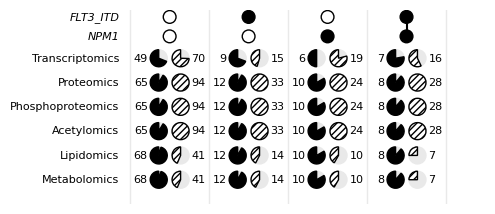

In [22]:
# --- setup ---

# figure and subpanels
fig, ax = plt.subplots(
    figsize=(5, 2.5),
)

# max font size 
rcParams["font.size"] = 8

# colors
c_white = "w"
c_black = "k"
c_border = c_black
c_grey = "#E9E9E9"

# misc parameters
w = 0.35            # bar width
lw = 1.             # line width for borders
r = 0.35           # circle radius
hatch = "/////"      # hatching for white bars
xfactor = 3.25
xoff = 0.45


# --- helper: make a pie ---

def _add_pie(x, y, has_block, total, black=True):
    theta_0 = 90
    proportion = has_block / total
    ax.add_patch(patches.Wedge(
        center=(x, y),
        r=r,
        theta1=theta_0,
        theta2=360 * proportion + theta_0,
        facecolor=c_black if black else c_white,
        edgecolor=c_border,
        hatch=None if black else hatch
    ))
    ax.text(
        x - xoff if black else x + xoff,
        y,
        str(has_block),
        ha="right" if black else "left",
        va="center" 
    )


# --- plot the data ---


# draw dividing lines
for x in np.arange(0, 5 * xfactor, xfactor):
    ax.axvline(
        x + xfactor / 2,
        lw=lw,
        c=c_grey
    )

# plot the field of empty circles
for x in np.arange(xfactor, 5 * xfactor, xfactor):
    for y in range(1, 7):
        for _x in [x - xoff, x + xoff]:
            ax.add_patch(patches.Circle(
                xy=(
                    _x, 
                    y
                ),
                radius=r,
                edgecolor=c_grey,
                lw=lw,
                facecolor=c_grey
            ))

# add block labels
block_to_y = {
    "Transcriptomics": 6,
    "Proteomics": 5,
    "Phosphoproteomics": 4,
    "Acetylomics": 3,
    "Lipidomics": 2,
    "Metabolomics": 1,
}
for blk, y in block_to_y.items():
    ax.text(
        xfactor / 2 - xoff,
        y,
        blk,
        ha="right",
        va="center"
    )

# add pies
mut_to_x = {
    "WT": xfactor,
    "FLT3-ITD": 2 * xfactor,
    "NPM1": 3 * xfactor,
    "NPM1xFLT3-ITD": 4 * xfactor
}
for (black, mut, block), (has_block, total) in omics_counts.items():
    if has_block > 0:
        _add_pie(
            mut_to_x[mut] - xoff if black else mut_to_x[mut] + xoff,
            block_to_y[block],
            has_block,
            total, 
            black=black
        )

# add the mutation indicator circles
ax.add_patch(patches.Circle(
    xy=(
        xfactor, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 2, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 2, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 3, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 3, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.plot(
    [xfactor * 4, xfactor * 4], 
    [6.9, 7.7], 
    "k-", 
    lw=1.5,
    zorder=-1
)
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 4, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 4, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.text(
    xfactor / 2 - xoff,
    7.7,
    "FLT3_ITD",
    ha="right",
    va="center",
    fontstyle="italic"
)
ax.text(
    xfactor / 2 - xoff,
    6.9,
    "NPM1",
    ha="right",
    va="center",
    fontstyle="italic"
)

# --- customization ---

ax.set_xlim((0, 5 * xfactor))
ax.set_ylim((0, 8))
ax.set_aspect("equal")
ax.set_axis_off()


# --- finish ---
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "mutations_omics_coverage_sample_counts.png"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

## Create Subsets

### Utility function for selecting subsets and applying transformations/normalizations
- filter columns to only include the selected samples for the subset (with two sample groups)
- filter rows to remove those that do not have at least 5 non-null values in WT and mutant groups
- apply row-wise z-score normalization across subset samples that are not null
    - require at least 5 samples within WT and mutant groups to z-score normalize

In [23]:
def select_subset(
    combined: pl.DataFrame,
    wt_cols: List[str],
    mut_cols: List[str]
) -> pl.DataFrame :
    """
    Select a subset of the combined -omics data DataFrame that contains a specified
    set of samples belonging to WT/mutant groups. 
    Filters rows with fewer than 5 
    Applies a row-wise z-score normalization to the full table 
    using non-null values from WT and mutant sample groups (no imputation).
    Returns the processed DataFrame with the selected subset.
    """
    return (
        combined
        .select(
            "Block",
            "Feature",
            *wt_cols,
            *mut_cols
        )
        .filter(
            (pl.sum_horizontal(~pl.col(wt_cols).is_null()) >= 5)
            & (pl.sum_horizontal(~pl.col(mut_cols).is_null()) >= 5)
        )
        .select(
            "Block",
            "Feature",
            (
                # pack the raw values into a list column
                pl.concat_list(
                    pl.col(wt_cols + mut_cols)
                )
                # compute row-wise z-scores
                .map_elements(
                    lambda x: stats.zscore(x, nan_policy="omit"), 
                    return_dtype=pl.List(pl.Float64)
                )
                # convert list to struct 
                .list.to_struct(
                    fields=wt_cols + mut_cols
                )
                .alias("packed")
            )
        )
        # unpack struct with z-scores back to sample columns
        .unnest("packed")
        # z-score makes NaNs out of null values, change them back
        .fill_nan(None)
    )

### Utility function to plot feature counts from the -omics data blocks before/after subsetting

In [24]:
def plot_filtered_feature_counts(
    combined: pl.DataFrame, 
    subset: pl.DataFrame, 
    figname=None
) :

    def _hex_to_rgba(hex: str, alpha: float) -> str : 
        """ add some transparency to rgb hex code and format it how plotly likes it """
        # assume the hex string starts with #
        ir = int(hex[1:3], 16)
        ig = int(hex[3:5], 16)
        ib = int(hex[5:7], 16)
        return f"rgba({ir}, {ig}, {ib}, {alpha})"

    # feature counts 
    counts = (
        combined
        .group_by("Block").len()
        .rename({"len": "pre"})
        .join(
            (
                subset
                .group_by("Block").len()
                .rename({"len": "post"})
            ), 
            how="left", 
            on="Block"
        )
        .fill_null(0)
        .sort("pre", descending=True)
    )

    # node: 
    #   key: {
    #       "index": index, 
    #       "color": color, 
    #       "label": label
    #       "count": count 
    #       "filtered": label <- for source nodes only
    # }
    node_data = {}

    # construct the node data from feature counts pre- and post-subsetting
    i = 0
    filtered = 0
    for block, pre, post in counts.iter_rows() :
        # add the node for pre-subsetting feature count
        node_data[f"{block}_0"] = {
            "index": i,
            "color": COLORS[block],
            "label": f"{block} ({pre})",
            "count": pre,
            "filtered": pre - post
        }
        filtered += pre - post
        i += 1
        # add the node for post-subsetting feature count
        node_data[f"{block}_1"] = {
            "index": i,
            "color": COLORS[block],
            "label": f"({post}) {block}",
            "count": post
        }
        i += 1

    # add a catch-all node for features that were filtered out
    node_data["Filtered"] = {
        "index": i,
        "color": COLORS["Filtered"],
        "label": f"({filtered}) Filtered",
        "count": filtered
    }

    # construct the link data from the node data
    link_data = {"source": [], "target": [], "value": [], "color": []}
    for block, pre, post in counts.iter_rows():
        # if features for a given block remained after subsetting, add a link
        if post > 0:
            link_data["source"].append(node_data[f"{block}_0"]["index"])
            link_data["target"].append(node_data[f"{block}_1"]["index"])
            link_data["value"].append(node_data[f"{block}_1"]["count"])
            link_data["color"].append(_hex_to_rgba(node_data[f"{block}_0"]["color"], 0.25))
        # always add the link from the block to filtered node
        link_data["source"].append(node_data[f"{block}_0"]["index"])
        link_data["target"].append(node_data["Filtered"]["index"])
        link_data["value"].append(node_data[f"{block}_0"]["filtered"])
        link_data["color"].append(_hex_to_rgba(node_data["Filtered"]["color"], 0.25))

        fig = pgo.Figure(
        data=[
            pgo.Sankey(
                arrangement="freeform",
                node=dict(
                    pad=15,
                    thickness=20,
                    line=dict(color="black", width=0.75),
                    label=[v["label"] for v in sorted(node_data.values(), key=lambda x: x["index"])],
                    color=[v["color"] for v in sorted(node_data.values(), key=lambda x: x["index"])],
                ),
                link=link_data
            )
        ]
    )
    if figname is not None:
        fig.write_image(figname, width=600, height=350, scale=4)
    fig.show()

### NPM1 vs. WT
#### Black patients

In [25]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "Black")
    & pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "B_NPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "B_NPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_NPM1-WT.png")
)

wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
mut_cols=['16-00611', '16-01267', 'C-00-1828', 'C-08-0176', 'C-97-0509',

Block,Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",-0.985217,null,-0.320516,0.65097,null,null,null,null,null,null,1.373828,1.144366,0.662258,1.492637,0.352981,1.40534,0.744819,-0.103337,1.483581,-2.421699,1.588216,-0.552605,0.799908,-0.169753,0.120497,0.690758,-1.366443,-0.103957,-0.214604,-1.366248,-0.662198,-0.431685,null,-0.188416,0.35666,…,-0.609843,0.923855,-0.826142,-0.339836,-0.009136,-1.814014,-0.559311,0.194596,-0.776956,1.005463,-0.223367,-1.304995,-0.299655,0.495833,-0.130135,-1.142249,-1.547083,0.038407,-0.892615,0.299408,-0.618696,0.371588,-0.886695,1.814485,0.842803,-1.837398,null,null,null,1.137056,0.365553,1.219235,-1.026123,-0.084956,0.535161,1.741551,-0.525197
"""Acetylomics""","""ACAD9-K202k""",null,-0.615981,-1.909239,-0.489651,null,null,null,null,null,null,null,0.49373,-0.91244,-1.039194,null,null,null,-1.556288,-1.706814,null,1.223755,-0.315223,null,0.962776,0.294771,1.144422,null,0.587042,null,0.728757,1.047575,-0.326516,0.497847,0.665968,0.625607,…,1.510444,1.029063,null,0.725177,null,-0.976801,-0.382375,null,null,1.259568,-0.293697,null,-1.695292,0.59783,null,-0.941923,null,1.837691,-1.141505,null,-1.091601,null,1.616445,-1.890603,0.092405,null,-0.044239,null,null,-0.483519,0.519386,0.220829,-0.175035,0.163434,-2.25029,1.118993,-1.120101
"""Acetylomics""","""ACADM-K304k""",null,-0.678301,-0.750208,-0.063816,null,null,null,null,null,null,null,0.718827,0.419007,0.227063,-0.449557,0.496895,0.068768,-1.215625,-0.572255,-0.393207,1.780824,-1.087425,1.087221,1.491485,0.897837,0.774193,null,0.253379,null,0.049016,0.322466,0.395976,0.326859,-0.809655,-0.000658,…,-1.31036,1.02116,null,-0.01779,0.84583,-1.163789,0.226669,null,-1.304343,0.936874,-0.647619,null,-2.914466,0.430881,null,-1.31519,-1.37082,1.143277,-1.131148,null,-1.53222,0.769216,-1.180709,0.279084,0.304962,null,1.353421,null,null,-1.411057,-0.240456,0.534927,0.322291,0.748379,0.743715,2.282235,0.159887
"""Acetylomics""","""ACADVL-K278k""",null,null,-0.558571,-1.446914,null,null,null,null,null,null,0.366006,0.244718,0.293471,1.422577,-0.079951,-1.91651,-0.886565,-1.047041,0.562909,-0.975941,0.174007,0.46546,0.707448,0.543218,0.318328,0.958388,-0.204386,-0.399425,0.395759,-0.00752,0.092212,-0.706294,0.504962,1.254531,-0.516901,…,-0.71208,0.262576,-1.510231,0.329567,0.598718,-1.225687,-0.093939,-0.113427,-0.856787,-1.891903,-0.748777,-0.445648,-0.827466,1.615464,0.685283,-0.449116,0.281045,0.328865,-1.000903,-0.926497,-0.089373,1.630105,-2.37135,1.407588,0.704384,-1.446914,1.983679,null,null,0.080571,0.894905,0.975936,0.545286,0.695717,0.315873,1.948119,1.546314
"""Acetylomics""","""ACADVL-K298k""",null,0.660351,-0.426601,0.207109,null,null,null,null,null,null,0.15798,0.234838,-1.217496,-0.497929,-2.343823,1.362601,null,-1.477265,-0.852518,-1.048008,0.125452,-1.213867,0.506368,1.366012,0.826649,1.230954,-3.051361,-0.2072,0.092713,0.349723,0.204332,2.104347,-0.344771,-0.445666,0.157468,…,0.073946,0.076915,-0.552613,0.32806,0.379565,-1.099899,-1.59634,-0.389294,

#### White patients 

In [26]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "White")
    & pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "W_NPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "W_NPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_W_NPM1-WT.png")
)

wt_cols=['13-00033', '13-00034', '13-00077', '13-00149', '13-00160', '13-00186', '13-00226', '13-00468', '13-00558', '13-00602', '14-00127', '14-00193', '14-00528', '14-00423', '14-00434', '14-00514', '14-00608', '14-00613', '14-00711', '14-00712', '15-00043', '15-00888', '15-00137', '15-00302', '15-00287', '15-00377', '15-00563', '15-00578', '15-00742', '15-00777', '15-00813', '15-00837', '15-00855', '15-00870', '15-00976', '16-00001', '16-00094', '16-00306', '16-00351', '16-00354', '16-00479', '16-00481', '16-00494', '16-00519', '16-00627', '16-00751', '16-00882', '16-00818', '16-00817', '18-00149', '16-01004', '16-01100', '16-01102', '16-01191', '16-01201', '16-01220', '16-01227', '16-01270', '17-00072', '17-00322', '17-00325', '17-00328', '17-00361', '18-00251', '17-00500', '17-00678', '17-00676', '17-00689', '17-00741', '17-00763', '17-00770', '17-00878', '17-00881', '17-00896', '17-00901', '18-00103', '18-00101', '18-00105', '18-00190', '18-00203', '18-00218', '18-00290', '18-004

Block,Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,…,18-00290,18-00408,18-00414,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",0.794338,-0.097797,0.461602,2.503799,null,0.091125,-0.316644,null,-0.535491,-0.088865,-1.515835,-0.081049,-1.113872,-0.697393,-1.672154,-1.303688,null,-0.203871,-1.06251,null,-1.102706,1.132657,1.082412,-0.17484,2.09067,0.779823,-1.016731,-0.07435,-0.8057,null,0.811087,null,0.538645,null,0.276252,…,2.258155,0.970755,null,0.119486,-0.371356,0.099835,-1.835783,-1.17531,-1.144809,-0.559559,0.450071,-0.58707,0.394692,null,null,0.677099,1.175087,0.807737,null,1.208584,null,1.722204,0.653651,-0.421601,-0.354607,-1.045761,-1.102706,0.052191,null,null,1.124841,0.030496,-0.498644,1.122608,0.937258,null,0.573258
"""Acetylomics""","""ACAD9-K202k""",null,null,0.255725,null,-0.568483,0.328741,null,null,1.511839,1.277942,null,null,1.573716,-0.223206,-1.705791,0.110932,-0.580858,-1.108055,null,-0.298697,0.594814,1.400459,-0.558582,null,-0.158854,0.223549,null,null,-0.148953,0.235925,0.438883,null,1.097259,0.994543,-0.006635,…,null,null,-0.577146,null,1.734598,null,null,-0.832285,0.320652,0.51276,-0.681146,null,null,-2.955717,-0.104402,-0.518981,1.53659,-1.54491,0.598527,0.907914,-2.015179,null,-0.879108,0.406707,-1.767669,null,0.419082,null,null,0.451258,-0.865495,1.313831,0.946278,0.321316,null,-0.55487,null
"""Acetylomics""","""ACADM-K304k""",null,-0.38794,-0.997483,2.228116,-1.814767,-0.823328,2.43959,null,null,0.673161,-0.231201,0.214138,-0.983799,0.837364,-0.560851,null,-0.600658,null,-0.957676,-0.146611,0.380829,2.738141,0.648282,0.783874,1.817608,-0.302107,0.062623,null,0.363414,0.679381,1.158307,null,0.613451,0.317387,-0.17771,…,0.546277,null,0.084766,null,null,1.344901,null,-0.88376,-0.834537,-1.317733,-1.235631,-0.738946,null,-0.096231,-1.466457,0.729139,1.307582,0.90827,1.693211,0.292508,-1.416699,-0.883038,0.589815,0.313655,null,-0.103446,-0.146611,null,null,-1.528655,0.21165,0.999079,0.673161,-0.257324,-0.432723,-0.373013,null
"""Acetylomics""","""ACADVL-K278k""",-1.713605,0.826433,null,1.50765,null,-0.983102,0.371585,null,null,0.981335,-2.250481,0.363048,1.358028,-1.044711,0.063366,null,null,-0.939096,-0.05017,-3.403444,null,1.092231,null,0.015839,1.0139,-0.152265,0.399573,0.926768,null,1.01654,null,-0.675059,null,null,0.844036,…,0.553595,null,0.595841,1.50765,null,-0.595848,0.303914,-0.245066,-1.554308,-0.572004,-0.622089,-0.067045,-1.344056,0.94085,0.103851,-0.419823,0.455901,0.759544,0.515749,0.353367,-0.912692,0.397813,0.858998,0.822913,-1.475972,0.371673,0.081848,-0.991903,null,0.220116,null,-0.89509,-1.071115,0.388836,-0.022887,null,-0.859885
"""Acetylomics""","""ACADVL-K298k""",null,null,0.442659,1.308385,0.598668,-0.625113,null,null,-0.490842,0.964396,-1.882142,0.154296,0.934984,-0.081636,-0.837388,null,null,-1.536875,1.202247,-2.150683,null,0.055192,-0.162199,0.863373,-0.575241,-1.626388,-0.102097,0.239718,0.894064,0.141764,1.298155,-1.127669,0.74189,0.411968,null,…,-0.222301,0.459283,0.139718,-0.229974,-0.261943,null,0.590973,-1.089246,-0.636598,-0.025848,-0.401119,-1.455451,-0.2576,-0.57140

### FLT3-ITD vs. WT
#### Black patients

In [27]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "B_FLT3-ITD-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "B_FLT3-ITD-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_FLT3-ITD-WT.png")
)

wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
mut_cols=['16-00088', 'C-09-0143', 'C-08-2480', 'C-12-0858', 'C-09-2182'

Block,Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",-1.026641,null,-0.333368,0.679877,null,null,null,null,null,null,1.433807,1.194481,0.69165,1.557723,0.369079,1.466673,0.77776,-0.106853,1.548278,-2.524869,1.65741,-0.575434,0.835217,-0.176125,0.126602,0.721375,-1.424253,-0.107501,-0.222903,-1.42405,-0.689737,-0.449316,null,-0.195589,0.372916,…,0.964492,-0.860728,-0.353518,-0.008603,-1.891063,-0.582428,0.203886,-0.809428,1.049608,-0.232043,-1.360165,-0.31161,0.518072,-0.134803,-1.190422,-1.612658,0.040984,-0.930058,0.313203,-0.644365,0.388485,-0.923884,1.893405,0.879956,-0.362007,null,1.444667,-0.347126,-0.326252,0.756903,-1.276762,-0.135091,0.64036,-0.72912,0.434021,1.655205,-0.222671
"""Acetylomics""","""ACAD9-K202k""",null,-0.703557,-2.033064,-0.573686,null,null,null,null,null,null,null,0.43726,-1.008325,-1.138632,null,null,null,-1.67022,-1.824965,null,1.187747,-0.394369,null,0.919453,0.232724,1.10619,null,0.533187,null,0.678874,1.006629,-0.405978,0.441492,0.614325,0.572833,…,0.987598,null,0.675194,null,-1.07449,-0.463402,null,null,1.224564,-0.372239,null,-1.81312,0.544277,null,-1.038635,null,1.818892,-1.24381,null,-1.192508,null,1.591444,-2.013906,0.024686,null,null,1.365929,null,null,null,-0.131769,0.491065,null,-1.201931,0.138725,0.405024,-0.151745
"""Acetylomics""","""ACADM-K304k""",null,-0.541539,-0.61327,0.071435,null,null,null,null,null,null,null,0.852154,0.553071,0.361599,-0.313358,0.630767,0.203693,-1.077543,-0.435755,-0.257146,1.91154,-0.949658,1.219643,1.622912,1.030724,0.907384,null,0.38785,null,0.183989,0.456767,0.530097,0.461149,-0.672571,0.134438,…,1.153744,null,0.117347,0.978845,-1.025835,0.361206,null,-1.166043,1.069665,-0.510933,null,-2.772208,0.564915,null,-1.176863,-1.232356,1.27556,-0.993274,null,-1.393359,0.902419,-1.042712,0.413492,0.439306,-1.744012,null,1.800093,null,-0.600156,null,-1.238945,0.976363,null,-0.139588,-0.591504,-0.009745,-1.265277
"""Acetylomics""","""ACADVL-K278k""",null,null,-0.571502,-1.435405,null,null,null,null,null,null,0.327638,0.209687,0.257099,1.355141,-0.106049,-1.892081,-0.890472,-1.046532,0.519124,-0.977388,0.140921,0.424356,0.659687,0.499975,0.281272,0.903723,-0.227061,-0.416734,0.356573,-0.035611,0.061377,-0.71516,0.462771,1.191718,-0.530978,…,0.227054,-1.496979,0.292202,0.553948,-1.220264,-0.119653,-0.138604,-0.861513,-1.868151,-0.756475,-0.461686,-0.832999,1.542721,0.638131,-0.465058,0.245015,0.291519,-1.001664,-0.929305,-0.115212,1.556959,-2.334407,1.340564,0.656707,0.251664,null,2.342539,0.188364,-0.07537,1.908212,-1.062734,2.124438,0.841959,-0.315262,0.824621,1.752055,0.334349
"""Acetylomics""","""ACADVL-K298k""",null,0.711119,-0.411691,0.242925,null,null,null,null,null,null,0.192175,0.271569,-1.228678,-0.485372,-2.392163,1.436537,null,-1.497017,-0.851659,-1.053599,0.158574,-1.224929,0.552056,1.44006,0.882903,1.300546,-3.123042,-0.185052,0.124755,0.390243,0.240057,2.202752,-0.327161,-0.431385,0.191646,…,0.108436,-0.54186,0.367866,0.42107,-1.107201,-1.620019,-0.373154,0.12687,

#### White patients

In [28]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "W_FLT3-ITD-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "W_FLT3-ITD-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_W_FLT3-ITD-WT.png")
)

wt_cols=['13-00033', '13-00034', '13-00077', '13-00149', '13-00160', '13-00186', '13-00226', '13-00468', '13-00558', '13-00602', '14-00127', '14-00193', '14-00528', '14-00423', '14-00434', '14-00514', '14-00608', '14-00613', '14-00711', '14-00712', '15-00043', '15-00888', '15-00137', '15-00302', '15-00287', '15-00377', '15-00563', '15-00578', '15-00742', '15-00777', '15-00813', '15-00837', '15-00855', '15-00870', '15-00976', '16-00001', '16-00094', '16-00306', '16-00351', '16-00354', '16-00479', '16-00481', '16-00494', '16-00519', '16-00627', '16-00751', '16-00882', '16-00818', '16-00817', '18-00149', '16-01004', '16-01100', '16-01102', '16-01191', '16-01201', '16-01220', '16-01227', '16-01270', '17-00072', '17-00322', '17-00325', '17-00328', '17-00361', '18-00251', '17-00500', '17-00678', '17-00676', '17-00689', '17-00741', '17-00763', '17-00770', '17-00878', '17-00881', '17-00896', '17-00901', '18-00103', '18-00101', '18-00105', '18-00190', '18-00203', '18-00218', '18-00290', '18-004

Block,Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,…,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",0.931684,0.142314,0.637275,2.444232,null,0.309474,-0.051324,null,-0.244962,0.150217,-1.11238,0.157133,-0.756719,-0.388215,-1.250693,-0.92467,null,0.048458,-0.711274,null,-0.74684,1.231032,1.186575,0.074145,2.078692,0.918841,-0.670768,0.16306,-0.484046,null,0.946503,null,0.705444,null,0.473276,…,-0.266257,0.627073,-0.290599,0.578074,-2.485628,-0.48207,-1.586595,-1.803944,-1.092621,1.426646,-0.663852,0.760769,null,null,0.131446,0.834865,-0.448479,-0.181733,-0.393154,0.166024,-0.517636,0.479204,-0.904911,0.661974,null,null,1.151008,null,-2.367074,1.584718,null,-1.260573,-0.509732,1.456284,-1.477921,-1.87474,-0.498295
"""Acetylomics""","""ACAD9-K202k""",null,null,0.280666,null,-0.641142,0.362328,null,null,1.685523,1.423929,null,null,1.754728,-0.254979,-1.913126,0.118727,-0.654983,-1.244608,null,-0.339409,0.659908,1.560955,-0.630069,null,-0.183006,0.24468,null,null,-0.171933,0.258521,0.485512,null,1.221851,1.106971,-0.012762,…,0.568137,-0.767146,null,null,-0.203767,null,-1.088205,-0.450137,null,0.126063,0.672365,0.035404,-0.64391,0.604545,-0.686817,0.790013,-1.222462,0.257136,0.240527,-0.660519,-0.886127,1.685523,null,-0.761558,-0.890279,-1.484056,1.127733,1.644001,0.446758,0.248832,null,-0.088887,-2.286832,0.205925,null,-0.717616,-0.481055
"""Acetylomics""","""ACADM-K304k""",null,-0.271984,-0.844612,2.18564,-1.6124,-0.681004,2.384306,null,null,0.724855,-0.124737,0.293632,-0.831757,0.879114,-0.434423,null,-0.47182,null,-0.807216,-0.04527,0.450228,2.664777,0.701483,0.828863,1.799993,-0.191349,0.151293,null,0.433867,0.730698,1.18062,null,0.668761,0.390628,-0.074486,…,-1.145467,-1.068337,-0.601732,null,-0.056957,null,-0.525576,0.627859,-1.226753,-1.355302,-1.156635,0.428024,null,1.566267,0.521514,null,null,0.853404,-0.793192,-0.468314,-0.32691,0.415169,null,-0.921741,null,-0.405208,0.994808,1.77662,-0.060463,-0.545443,0.730698,-1.343616,-0.303537,1.27411,-0.880839,-2.789818,-1.732953
"""Acetylomics""","""ACADVL-K278k""",-1.62379,0.803205,null,1.454104,null,-0.925798,0.3686,null,null,0.951213,-2.136773,0.360442,1.311142,-0.984665,0.074097,null,null,-0.88375,-0.034386,-3.238424,null,1.057174,null,0.028686,0.982329,-0.131937,0.395342,0.899074,null,0.984851,null,-0.631464,null,null,0.820024,…,-0.532995,-0.580851,-0.050509,-1.270688,0.530736,null,null,null,null,0.855344,-0.564187,1.479333,0.026163,-0.18744,1.252275,-0.757607,null,0.127077,0.021117,-0.081479,-1.026713,0.045505,-0.614645,1.496152,-1.901306,0.227908,0.828434,1.227046,0.718269,-1.598562,0.713223,-0.411975,-0.342175,0.517281,-1.783572,-1.253195,-0.866276
"""Acetylomics""","""ACADVL-K298k""",null,null,0.377649,1.196811,0.525268,-0.632692,null,null,-0.505643,0.871324,-1.82211,0.104797,0.843495,-0.118446,-0.83355,null,null,-1.495413,1.096382,-2.076208,null,0.011022,-0.194676,0.775735,-0.585502,-1.580113,-0.137806,0.185624,0.804775,0.092939,1.187132,-1.108217,0.660786,0.348609,null,…,-0.065659,-0.420746,-1.418369,-0.284946,-0.602442,-2.499704,null,2.800047,-0.64

### FLT3-ITDxNPM1

#### Black patients

In [29]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "Black")
    & pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "B_FLT3-ITDxNPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "B_FLT3-ITDxNPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_FLT3-ITDxNPM1-WT.png")
)

wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
mut_cols=['17-00313', 'C-09-0261', 'C-05-0319', 'C-01-2143', 'C-12-1118'

Block,Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-03-2056,C-99-0740,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",-0.978678,null,-0.290474,0.715362,null,null,null,null,null,null,1.463779,1.226203,0.727049,1.586789,0.406837,1.496405,0.812529,-0.065616,1.577413,-2.465951,1.685747,-0.53077,0.869566,-0.134381,0.166132,0.756556,-1.373383,-0.066258,-0.180817,-1.373181,-0.644237,-0.405574,null,-0.153703,0.410645,…,0.665288,-0.776273,1.0679,-0.590031,0.997896,-0.813979,-0.310477,0.031916,-1.836779,-0.537713,0.242852,-0.763053,1.082389,-0.18989,-1.309763,-0.268876,0.55474,-0.093362,-1.141262,-1.56041,0.08114,-0.882801,0.351369,-0.599197,0.426101,-0.876672,1.920016,0.913978,-1.586493,null,1.051043,-0.069966,-0.352172,1.053403,-0.221609,-0.092435,-0.809585
"""Acetylomics""","""ACADM-K304k""",null,-0.622744,-0.696229,0.005222,null,null,null,null,null,null,null,0.805036,0.498638,0.302483,-0.388982,0.578235,0.140715,-1.171857,-0.514372,-0.331395,1.890333,-1.040845,1.181514,1.594646,0.987974,0.861618,null,0.329377,null,0.12053,0.399979,0.475102,0.404469,-0.756981,0.069766,…,0.644261,-1.401837,0.364803,-1.26867,1.114003,null,0.052258,0.934826,-1.118884,0.302081,null,-1.262522,1.027867,-0.59139,null,-2.907971,0.510773,null,-1.273607,-1.330457,1.238799,-1.085527,null,-1.495398,0.856531,-1.136175,0.355646,0.382091,-1.707656,null,0.981103,1.325695,0.053056,null,0.179932,-0.043885,null
"""Acetylomics""","""ACADVL-K278k""",null,null,-0.458083,-1.320412,null,null,null,null,null,null,0.43942,0.321683,0.369009,1.465051,0.006522,-1.776256,-0.776471,-0.932248,0.630557,-0.86323,0.253043,0.535961,0.770863,0.611442,0.393138,1.014455,-0.114269,-0.303597,0.468302,0.076832,0.173644,-0.601479,0.574306,1.301926,-0.417632,…,-0.304353,-1.488431,0.844437,-0.607096,0.339018,-1.381874,0.404048,0.665317,-1.105663,-0.007057,-0.025973,-0.747566,-1.75237,-0.642719,-0.348467,-0.719103,1.652289,0.749347,-0.351833,0.356946,0.403366,-0.887461,-0.815235,-0.002624,1.666501,-2.217777,1.4505,0.767889,-1.308727,null,1.660184,1.293403,1.007543,1.834981,-0.039696,0.112073,-2.541353
"""Acetylomics""","""ACADVL-K298k""",null,0.719984,-0.413172,0.247476,null,null,null,null,null,null,0.196258,0.276384,-1.237687,-0.487532,-2.411893,1.452086,null,-1.508499,-0.857194,-1.060995,0.162348,-1.233903,0.559455,1.455642,0.893352,1.314843,-3.149507,-0.184445,0.128217,0.396152,0.244581,2.225362,-0.327863,-0.433048,0.195724,…,-0.90136,0.954572,-0.126742,0.108652,0.111748,-0.544541,0.373568,0.427263,-1.115091,-1.632635,-0.374279,0.130352,-0.808451,0.72186,-0.056398,-0.567566,1.374563,0.561324,-1.265084,0.877011,0.137528,-0.231539,1.191166,-0.49615,0.40529,-0.695503,0.194131,-0.012482,-0.75132,null,1.889113,0.470277,0.814589,2.093324,0.322366,0.926001,-1.070427
"""Acetylomics""","""ACAT1-K190k""",null,-0.576503,null,-0.864663,null,null,null,null,null,null,-0.085341,-0.63452,-1.164117,0.232019,-0.136824,-0.986082,-2.702805,-0.863092,-1.290547,-0.464433,1.34273,-0.53339,0.811822,-0.438285,0.604971,1.058684,-0.53718,-0.316836,-0.326379,-0.794027,0.209534,0.334387,-0.681

#### White patients

In [30]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "White")
    & pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "W_FLT3-ITDxNPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "W_FLT3-ITDxNPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_W_FLT3-ITDxNPM1-WT.png")
)

wt_cols=['13-00033', '13-00034', '13-00077', '13-00149', '13-00160', '13-00186', '13-00226', '13-00468', '13-00558', '13-00602', '14-00127', '14-00193', '14-00528', '14-00423', '14-00434', '14-00514', '14-00608', '14-00613', '14-00711', '14-00712', '15-00043', '15-00888', '15-00137', '15-00302', '15-00287', '15-00377', '15-00563', '15-00578', '15-00742', '15-00777', '15-00813', '15-00837', '15-00855', '15-00870', '15-00976', '16-00001', '16-00094', '16-00306', '16-00351', '16-00354', '16-00479', '16-00481', '16-00494', '16-00519', '16-00627', '16-00751', '16-00882', '16-00818', '16-00817', '18-00149', '16-01004', '16-01100', '16-01102', '16-01191', '16-01201', '16-01220', '16-01227', '16-01270', '17-00072', '17-00322', '17-00325', '17-00328', '17-00361', '18-00251', '17-00500', '17-00678', '17-00676', '17-00689', '17-00741', '17-00763', '17-00770', '17-00878', '17-00881', '17-00896', '17-00901', '18-00103', '18-00101', '18-00105', '18-00190', '18-00203', '18-00218', '18-00290', '18-004

Block,Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,…,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",0.76262,-0.103293,0.439664,2.421836,null,0.080077,-0.315707,null,-0.528122,-0.094623,-1.479651,-0.087037,-1.089502,-0.685265,-1.631376,-1.273739,null,-0.206249,-1.03965,null,-1.078665,1.090996,1.042227,-0.178072,2.02085,0.748532,-0.995216,-0.080534,-0.790388,null,0.778877,null,0.514442,null,0.259762,…,-0.368811,0.08853,-1.790195,-1.149135,-1.11953,-0.551482,0.428472,-0.578184,0.374721,-1.392951,-0.038268,null,null,-1.447139,0.562127,0.024372,null,2.573561,null,0.277102,0.404984,null,null,0.389812,-1.479651,0.215328,null,2.1509,0.550206,0.032901,0.19257,0.733359,0.635822,1.25139,0.775625,0.564295,0.067079
"""Acetylomics""","""ACAD9-K202k""",null,null,0.23901,null,-0.66332,0.318946,null,null,1.614181,1.358115,null,null,1.681924,-0.285317,-1.908426,0.080492,-0.676868,-1.254034,null,-0.367963,0.610238,1.492245,-0.652481,null,-0.214865,0.203783,null,null,-0.204026,0.217332,0.439527,null,1.160307,1.047854,-0.048218,…,1.858054,null,null,-0.952126,0.31009,0.520406,-0.786662,null,null,-0.454673,-0.458738,1.255146,0.309462,-1.053516,null,0.969273,0.285074,2.941933,-0.414028,-1.664553,-0.553577,0.029008,-0.361188,null,-1.281131,0.360946,null,0.816175,-0.285317,0.029008,-0.598287,0.713207,-1.705199,-0.770353,-0.457383,0.005976,0.291913
"""Acetylomics""","""ACADM-K304k""",null,-0.443131,-1.026115,2.058942,-1.807789,-0.859548,2.261202,null,null,0.571738,-0.293221,0.132715,-1.013027,0.728786,-0.608508,null,-0.64658,null,-0.988042,-0.212317,0.292143,2.546745,0.547942,0.677626,1.66632,-0.361037,-0.012198,null,0.275486,0.577686,1.035745,null,0.514629,0.231465,-0.242061,…,null,1.21421,null,-0.917347,-0.870269,-1.332412,-1.253886,-0.778842,null,-0.098337,0.365908,0.345682,null,1.820989,0.064898,-1.296191,0.430156,1.583036,null,1.238005,0.820398,1.059541,null,null,-2.2599,0.354011,null,2.273099,-0.070735,0.225516,-0.653719,1.001242,-0.845271,-0.54545,-0.207558,0.655021,-0.09993
"""Acetylomics""","""ACADVL-K278k""",-1.875764,0.65362,null,1.331979,null,-1.148325,0.20068,null,null,0.807873,-2.410388,0.192179,1.182986,-1.209675,-0.106247,null,null,-1.104503,-0.219306,-3.558514,null,0.918303,null,-0.153574,0.840301,-0.320972,0.228551,0.753534,null,0.84293,null,-0.841573,null,null,0.671149,…,null,-0.762694,0.133293,-0.413385,-1.717134,-0.738951,-0.788826,-0.23611,-1.507765,0.841177,0.363521,1.384565,null,0.624698,1.147928,0.575618,-0.68031,-0.001951,-0.552351,0.553707,null,0.61681,0.777197,0.476581,1.244336,0.449412,null,1.57738,0.136815,0.580877,-0.018603,0.941967,-0.018603,0.733376,-0.569003,0.022589,0.439531
"""Acetylomics""","""ACADVL-K298k""",null,null,0.399338,1.280629,0.558153,-0.68763,null,null,-0.550945,0.930456,-1.967258,0.105792,0.900515,-0.134383,-0.903722,null,null,-1.615784,1.172583,-2.240628,null,0.004905,-0.216393,0.827617,-0.636861,-1.706907,-0.155211,0.192749,0.858859,0.093034,1.270214,-1.199221,0.70395,0.368096,null,…,-0.317931,null,0.55032,-1.160107,-0.699322,-0.077591,-0.459609,-1.532896,-0.31351,0.